In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn  Utilities

from sklearn.preprocessing import LabelEncoder

# Set a style for plots
sns.set_style("whitegrid")

---------------
Load the "encoded_crash_data.csv" dataset as encoded_crash_df.

In [ ]:
encoded_crash_df = pd.read_csv(
    "https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoded_crash_data.csv",
    dtype={'medication_use': str}  # To avoid slowing processing speed, specify data type
)

##For a full key to the encoding, see document crash_df_encoding.ipynb

In [ ]:
encoded_crash_df.columns.unique()

Index(['Vehicle_Num', 'Collision_Type', 'Weather', 'Surface_Condition',
       'Ambient_Light', 'Driver_At_Fault', 'Injury_Severity',
       'Drivers_License_State', 'Vehicle_Damage', 'Speed_Limit', 'Junction',
       'Intersection_Type', 'Road_Condition', 'Crash_Hour', 'Crash_Month',
       'Vehicle_Age', 'alc_drug_med', 'Driver_Distract_YN',
       'Injury_Severity_Encoded', 'Vehicle_Damage_Encoded',
       'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
       'substance_encoded', 'distract_encoded'],
      dtype='object')

## Exploratory Data Analysis

In [ ]:
eda_cols = ['Speed_Limit', 'Injury_Severity_Encoded', 'Vehicle_Damage_Encoded',
       'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
       'substance_encoded', 'distract_encoded']

print("Information about the selected columns in encoded_crash_df:")
encoded_crash_df[eda_cols].info()

print("\nDescriptive statistics for numerical columns:")
display(encoded_crash_df[eda_cols].describe())

print("\nValue counts for categorical/ordinal encoded columns:")
for col in ['Injury_Severity_Encoded', 'Vehicle_Damage_Encoded',
            'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
            'substance_encoded', 'distract_encoded']:
    print(f"\n-- {col} --")
    display(encoded_crash_df[col].value_counts(dropna=False).sort_index())

Information about the selected columns in encoded_crash_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214273 entries, 0 to 214272
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Speed_Limit                214273 non-null  int64  
 1   Injury_Severity_Encoded    211299 non-null  float64
 2   Vehicle_Damage_Encoded     204095 non-null  float64
 3   Surface_Condition_Encoded  189141 non-null  float64
 4   Ambient_Light_Encoded      211494 non-null  float64
 5   Weather_Encoded            199566 non-null  float64
 6   substance_encoded          43352 non-null   float64
 7   distract_encoded           168172 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 13.1 MB

Descriptive statistics for numerical columns:


,Speed_Limit,Injury_Severity_Encoded,Vehicle_Damage_Encoded,Surface_Condition_Encoded,Ambient_Light_Encoded,Weather_Encoded,substance_encoded,distract_encoded
count,214273.000000,211299.000000,204095.000000,189141.000000,211494.000000,199566.000000,43352.000000,168172.000000
mean,32.083720,0.293636,2.130410,0.213486,0.624401,0.439844,0.169427,0.199694
std,11.385475,0.678447,0.962014,0.446732,0.967615,0.901312,0.375133,0.399772
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,35.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,40.000000,0.000000,3.000000,0.000000,2.000000,0.000000,0.000000,0.000000
max,75.000000,4.000000,4.000000,2.000000,3.000000,5.000000,1.000000,1.000000



Value counts for categorical/ordinal encoded columns:

-- Injury_Severity_Encoded --


,count
Injury_Severity_Encoded,
0.0,173638
1.0,15411
2.0,20314
3.0,1738
4.0,198
NaN,2974



-- Vehicle_Damage_Encoded --


...

,count
Weather_Encoded,
0.0,149986
1.0,21011
2.0,24774
3.0,775
4.0,206
5.0,2814
NaN,14707



-- substance_encoded --


,count
substance_encoded,
0.0,36007
1.0,7345
NaN,170921



-- distract_encoded --


,count
distract_encoded,
0.0,134589
1.0,33583
NaN,46101


### Univariate Analysis: Feature Distributions

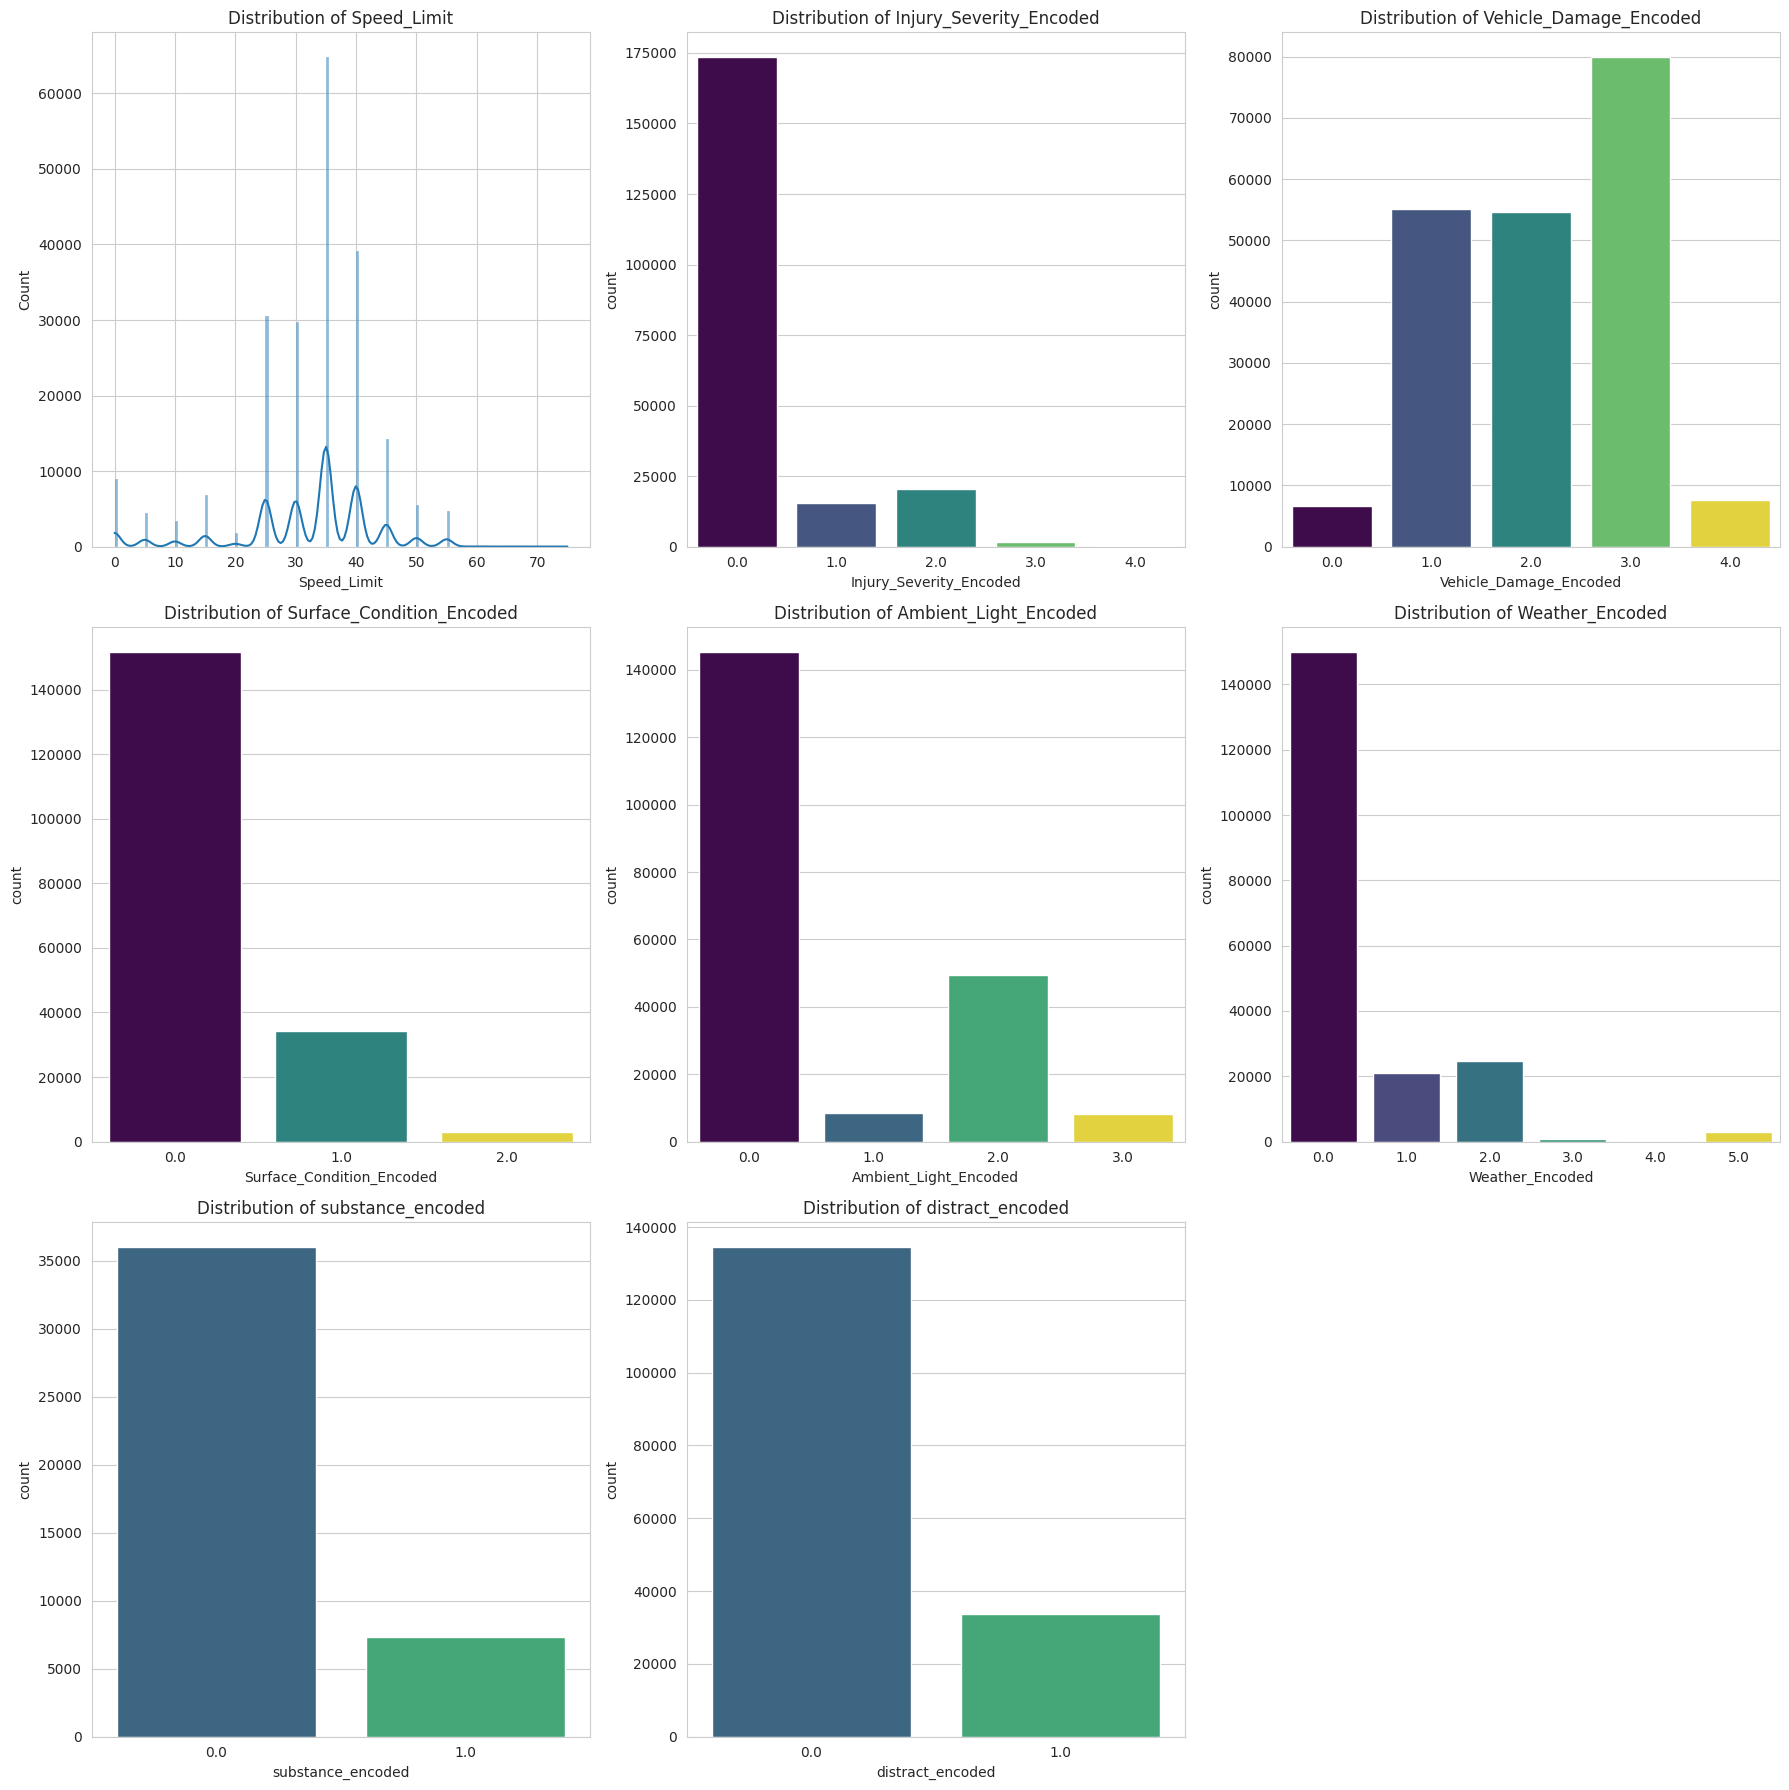

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 18))
axes = axes.flatten()

numerical_col = 'Speed_Limit'
categorical_ordinal_cols = [col for col in eda_cols if col != numerical_col]

# Plot numerical column
sns.histplot(encoded_crash_df[numerical_col].dropna(), kde=True, ax=axes[0])
axes[0].set_title(f'Distribution of {numerical_col}')

# Plot categorical/ordinal columns
for i, col in enumerate(categorical_ordinal_cols):
    ax_idx = i + 1 # Start from the second subplot
    if ax_idx < len(axes): # Ensure we don't go out of bounds
        sns.countplot(x=col, data=encoded_crash_df, ax=axes[ax_idx], palette='viridis', hue=col, legend=False)
        axes[ax_idx].set_title(f'Distribution of {col}')
        # Ensure integer ticks for encoded ordinal data
        min_val = encoded_crash_df[col].min()
        max_val = encoded_crash_df[col].max()
        if pd.notna(min_val) and pd.notna(max_val):
            axes[ax_idx].set_xticks(range(int(min_val), int(max_val) + 1))

# Hide any unused subplots
for j in range(len(eda_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Bivariate Analysis: Relationships between Variables

#### Relationship with Injury Severity

In [ ]:
target_col_injury = 'Injury_Severity_Encoded'
predictor_cols = ['Speed_Limit', 'Vehicle_Damage_Encoded',
       'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
       'substance_encoded', 'distract_encoded']

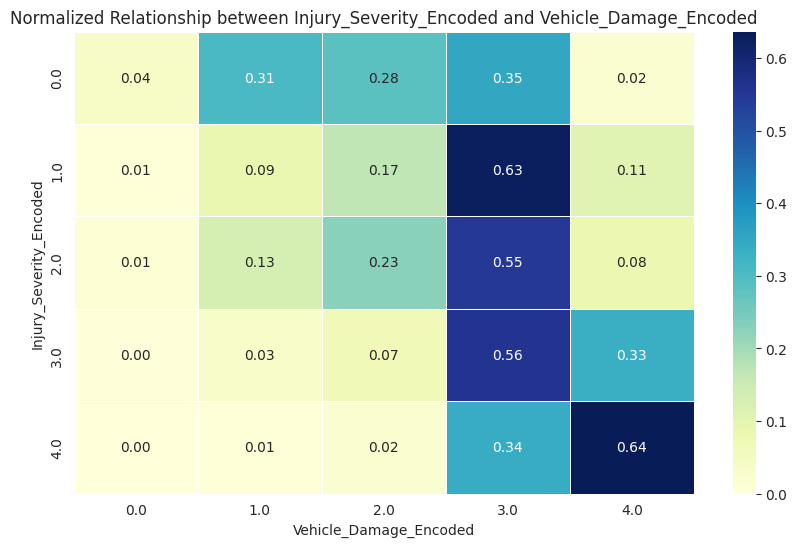

In [ ]:
# heatmap for Injury Severity vs Vehicle Damage as they are both ordinal
plt.figure(figsize=(10, 6))
ct = pd.crosstab(encoded_crash_df[target_col_injury], encoded_crash_df['Vehicle_Damage_Encoded'], normalize='index')
sns.heatmap(ct, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title(f'Normalized Relationship between {target_col_injury} and Vehicle_Damage_Encoded')
plt.ylabel(target_col_injury)
plt.xlabel('Vehicle_Damage_Encoded')
plt.show()

#### Relationship with Vehicle Damage

/tmp/ipykernel_1513/117398637.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=encoded_crash_df[target_col_damage].astype(str), y=col, data=encoded_crash_df, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_1513/117398637.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col_damage, data=encoded_crash_df, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_1513/117398637.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col_damage, data=encoded_crash_df, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_1513

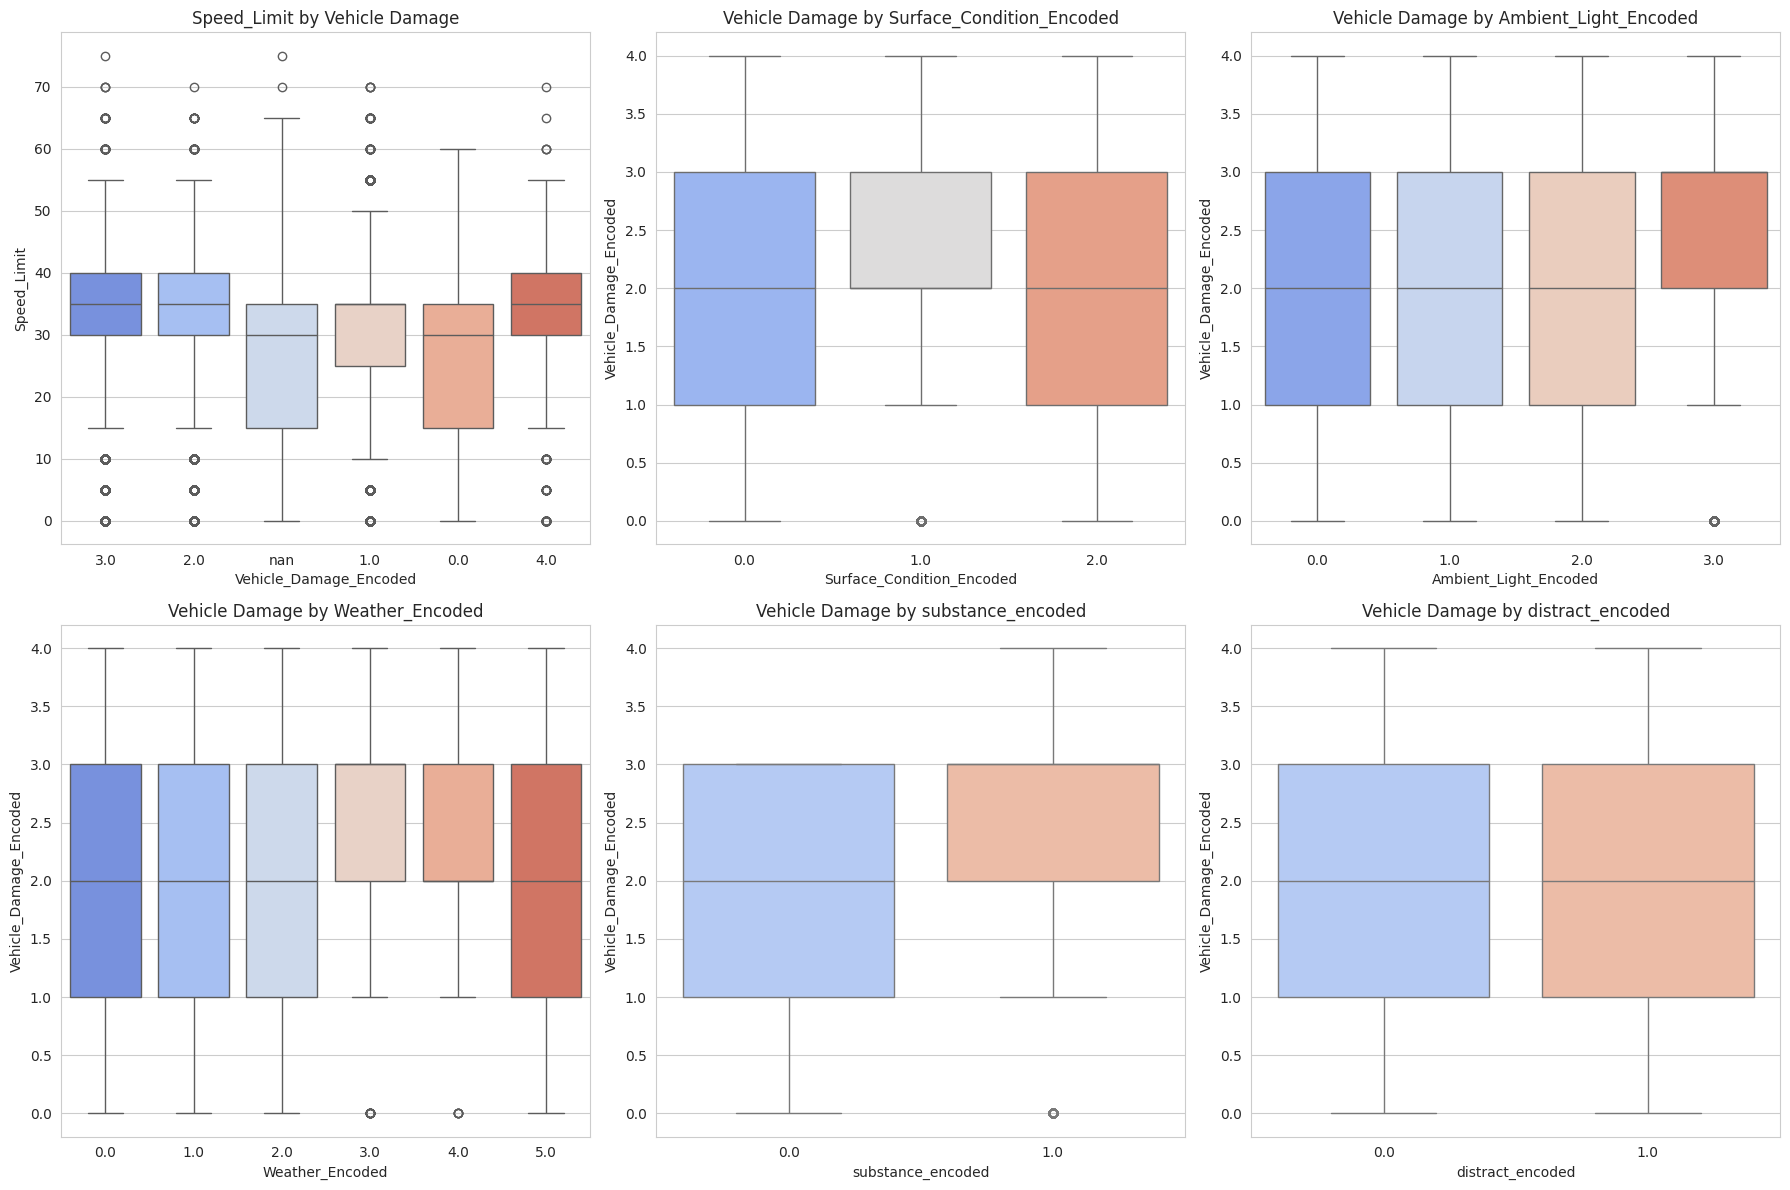

In [ ]:
target_col_damage = 'Vehicle_Damage_Encoded'
predictor_cols = ['Speed_Limit', 'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
       'substance_encoded', 'distract_encoded']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12)) # Adjusted layout for 6 predictors
axes = axes.flatten()

# Loop through predictor_cols and create boxplots against target_col_damage
for i, col in enumerate(predictor_cols):
    if col == 'Speed_Limit':
        # For Speed_Limit, use a boxplot with the target on the x-axis
        sns.boxplot(x=encoded_crash_df[target_col_damage].astype(str), y=col, data=encoded_crash_df, ax=axes[i], palette='coolwarm')
        axes[i].set_title(f'{col} by Vehicle Damage')
        axes[i].set_xlabel('Vehicle_Damage_Encoded')
    else:
        # For encoded categorical/ordinal predictors
        sns.boxplot(x=col, y=target_col_damage, data=encoded_crash_df, ax=axes[i], palette='coolwarm')
        axes[i].set_title(f'Vehicle Damage by {col}')

# Hide any unused subplots if the number of predictors is not a perfect fit
for j in range(len(predictor_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Matrix

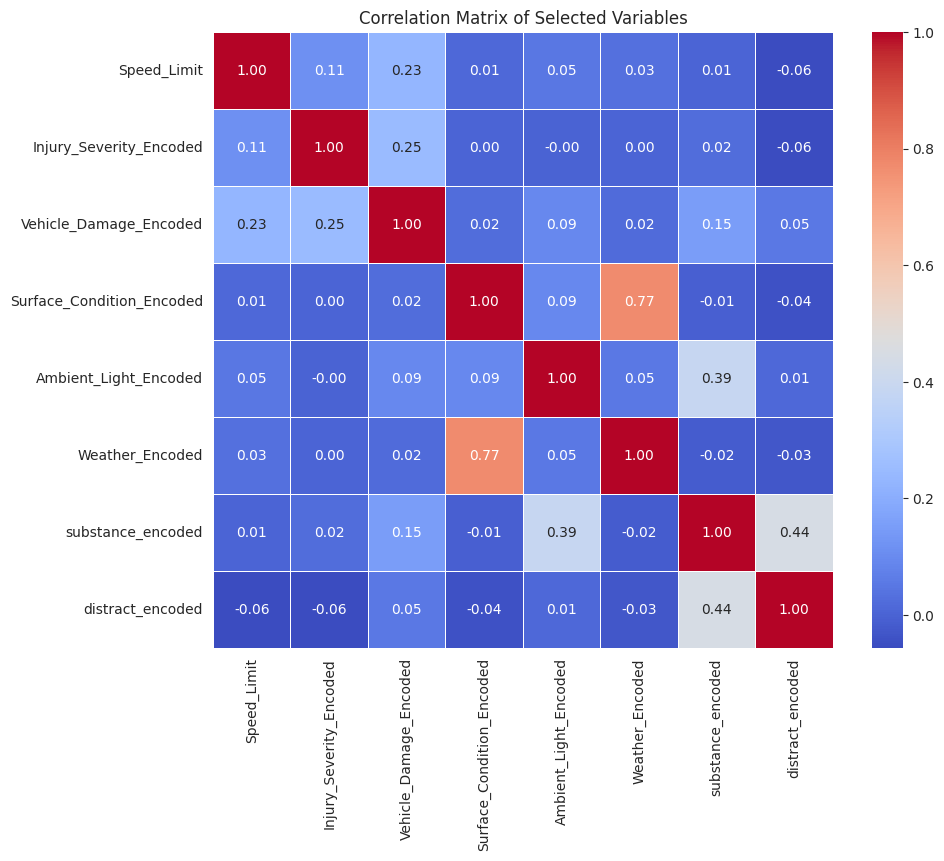

In [ ]:
# For correlation, all variables in eda_cols are already numerical.
correlation_df = encoded_crash_df[eda_cols].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Selected Variables')
plt.show()

------------------
##Encoding Keys

![Encoding key 1](https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoding_key_1.png)

![Encoding key 2](https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoding_key_2.png)